# 실습 1: 이미지 분류

## 1) Ultralytics 버전

In [ ]:
# FastSAM -> uv pip install git+http://github.com/ultralytics/CLIP.git (FastSAM 실습하면서 설치됨)

In [3]:
import clip
import torch
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

### 이미지 불러오기

In [2]:
image_path = "./images/dog.jpeg"
classes = ["a person", "a car", "a dog", "a cat"]

img = Image.open(image_path)

### 모델에 넣을 준비

In [8]:
image = preprocess(img).unsqueeze(0).to(device)
text = clip.tokenize(classes).to(device)

### 유사도 계산하기

In [12]:
with torch.no_grad():
    logit_per_image, _ = model(image, text)
    print(logit_per_image)
    print("="*20)
    print(_)
    probs = logit_per_image.softmax(dim=1).cpu().numpy()[0]
    print("="*20)
    print(probs)

tensor([[21.5625, 20.6719, 26.0938, 20.0469]], device='cuda:0',
       dtype=torch.float16)
tensor([[21.5625],
        [20.6719],
        [26.0938],
        [20.0469]], device='cuda:0', dtype=torch.float16)
[0.01058  0.00434  0.983    0.002325]


### 결과

In [11]:
for label, prob in zip(classes, probs):
    print(f"{label}: {prob:.4f}")

a person: 0.0106
a car: 0.0043
a dog: 0.9829
a cat: 0.0023


In [13]:
prob_test = torch.tensor([0.01058,  0.00434, 0.983, 0.002325])
classes = ["a person", "a car", "a dog", "a cat"]
# argmax = 최대값이 있는 곳의 위치
# "a dog"
print(prob_test.argmax())
print(classes[prob_test.argmax()])

tensor(2)
a dog


### unsqueeze란?

In [ ]:
# 데이터가 하나더라도 리스트로 묶어서 줘야함. -> unsqueeze

In [9]:
import torch

x1 = torch.tensor([1.0, 2.0, 3.0])
print(x1)
print(x1.shape)

x2 = x1.unsqueeze(0)
print(x2)
print(x2.shape)

tensor([1., 2., 3.])
torch.Size([3])
tensor([[1., 2., 3.]])
torch.Size([1, 3])


## 2) Huggingface 버전

In [14]:
from PIL import Image
import requests

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

c:\Users\user\Documents\pj03\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

### 이미지 불러오기

In [40]:
img_path = "./images/sit.jpg"
classes = [
    "a person standing",
    "a person sitting",
    "a person running"
]
image = Image.open(img_path)

### 모델에 넣을 준비

In [41]:
inputs = processor(text=classes, images=image, return_tensors="pt", padding=True)

### 유사도 계산하기

In [42]:
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1) # we can take the softmax to get the label probabilities

In [43]:
print(probs)

tensor([[0.4514, 0.5233, 0.0253]], grad_fn=<SoftmaxBackward0>)


In [44]:
for label, prob in zip(classes, probs[0]):
    print(f"{label}: {prob:.4f}")

a person standing: 0.4514
a person sitting: 0.5233
a person running: 0.0253


In [48]:
result = classes[probs[0].argmax()]
result

'a person sitting'

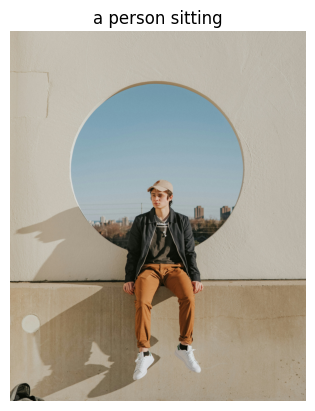

In [49]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")
plt.title(result)
plt.show()

# 실습 2: 이미지 검색

## 모델 불러오기

In [54]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model.to(device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

## 검색어 및 검색 대상 폴더 불러오기

In [56]:
img_folder = "./images/clothes"

# 파이썬으로 폴더 안에 있는 파일들 불러오기
import os

files = []

allow_extensions = ["jpg", "jpeg", "png"]
for file in os.listdir(img_folder):
    if file.split(".")[-1] in allow_extensions:
        files.append(os.path.join(img_folder, file))

print(files)

['./images/clothes\\image1.jpg', './images/clothes\\image2.jpg', './images/clothes\\image3.jpg', './images/clothes\\image4.jpg', './images/clothes\\image5.jpg']


## 폴더 이미지 벡터화 하기

In [ ]:
# VectorDB 도구 - 크로마디비, 페이즈?

In [75]:
from PIL import Image

image_features = []
for file in files:
    image = Image.open(file)
    inputs = processor(images=image, return_tensors = "pt").to(device)
    with torch.no_grad():
        feature = model.vision_model(pixel_values=inputs['pixel_values']).pooler_output
        feature = model.visual_projection(feature)
        feature /= feature.norm(dim=1, keepdim=True)

    image_features.append(feature.cpu())

image_features = torch.cat(image_features, dim=0)

In [76]:
# cat 예시
feat1 = torch.tensor([[1.0, 2.0, 3.0]])
feat2 = torch.tensor([[4.0, 5.0, 6.0]])

features = [feat1, feat2]
print(features)

features_cat = torch.cat(features, dim=0)
print(features_cat)

[tensor([[1., 2., 3.]]), tensor([[4., 5., 6.]])]
tensor([[1., 2., 3.],
        [4., 5., 6.]])


## 검색하기(=유사도 계산)

In [77]:
# 검색 설정
query = "a blue shirt"
top_k = 3

In [78]:
# 텍스트 벡터화
inputs = processor(
    text=[query], return_tensors= "pt"
).to(device)

with torch.no_grad():
    text_feature = model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    ).pooler_output

In [79]:
# 유사도 계산
similarity = (image_features @ text_feature.cpu().T).squeeze(1)
top_indices = similarity.argsort(descending=True)[:top_k]

print(similarity)
print(files)
print(top_indices)

tensor([ 1.6405,  0.9895, -0.0463, -0.8229, -0.5657])
['./images/clothes\\image1.jpg', './images/clothes\\image2.jpg', './images/clothes\\image3.jpg', './images/clothes\\image4.jpg', './images/clothes\\image5.jpg']
tensor([0, 1, 2])


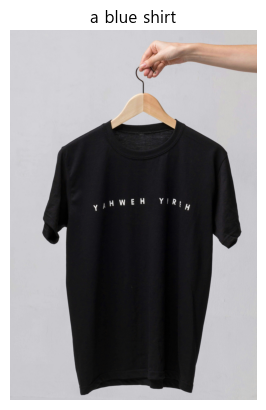

In [74]:
import matplotlib.pyplot as plt 

img = Image.open(files[2])

plt.imshow(img)
plt.title(query)
plt.axis("off")
plt.show()

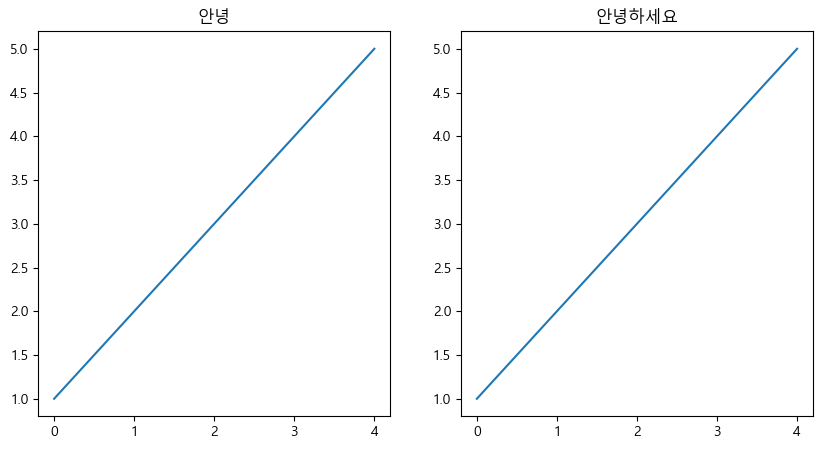

In [64]:
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt 

font_path = "C:/Windows/Fonts/malgun.ttf"

font_manager.fontManager.addfont(font_path)
rc('font', family="Malgun Gothic")
plt.rcParams['axes.unicode_minus']

fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].plot([1, 2, 3, 4, 5])
axes[0].set_title("안녕")

axes[1].plot([1, 2, 3, 4, 5])
axes[1].set_title("안녕하세요")

plt.show()

In [ ]:
# 예시 : 교실에 모자를 쓴 사람과 모자를 책상위에 올려놓은 사람이 있다. 
# -> 모자를 쓴 사람을 탐지하기 
# -> 모자를 찾는 모델과 사람을 찾는 모델을 엮어야 한다 
# -> 빨간 모자를 쓴 사람을 찾는다면?
# -> 모델 3개를 엮어야 한다 -> 점점 복잡해짐 -> 이를 CLIP으로 어느 정도 해결 가능

# 실습 3 : 모델 융합(YOLO+CLIP)

In [80]:
# 나는 이미지에서 사람이 앉아있는지 아닌지를 분류하고 싶습니다.
# sit.jpg 준비
# YOLO로 person 찾기
# CLIP 실습1을 활용해ㅐ서 person 분류하기

## 모델 불러오기

In [81]:
from ultralytics import YOLO

yolo_model = YOLO("./models/yolo26n.pt")

In [84]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [85]:
device = "cuda" if torch.cuda.is_available() else "cpu"
yolo_model = yolo_model.to(device)
clip_model = clip_model.to(device)

## 이미지/텍스트 준비하기

In [88]:
from PIL import Image

image_path = "./images/sit.jpg"
classes = [
    "a person standing",
    "a person sitting"
]

## YOLO로 객체 감지하기

In [89]:
yolo_result = yolo_model(source=image_path)[0]
yolo_result


image 1/1 c:\Users\user\Documents\pj03\images\sit.jpg: 640x512 1 person, 80.3ms
Speed: 11.0ms preprocess, 80.3ms inference, 27.2ms postprocess per image at shape (1, 3, 640, 512)


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [91]:
names = yolo_result.names
boxes = yolo_result.boxes

person_list = []
for data in boxes.data:
    x1, y1, x2, y2, conf, idx = data.to("cpu")
    if names[int(idx)] == "person":
        person_list.append(data.to("cpu"))

In [94]:
print(person_list)

[tensor([1.3058e+03, 1.6903e+03, 2.1976e+03, 3.9156e+03, 8.2755e-01, 0.0000e+00])]


## 객체 감지한 결과에서 CLIP으로 분류하기

In [97]:
plt.imshow(image)
plt.

SyntaxError: invalid syntax (3117299490.py, line 2)

In [95]:
x1, y1, x2, y2, conf, idx = person_list[0]
crop_image = image.crop([int(x1), int(y1), int(x2), int(y2)])

processor(
    text=classes,
    images=crop_image,
    return_tensors="pt",
    padding=True
)

{'pixel_values': tensor([[[[-0.8434, -0.8580, -1.0331,  ..., -1.5441, -1.5587, -1.5441],
          [-1.1061, -1.1353, -1.2229,  ..., -1.5003, -1.5295, -1.5295],
          [-1.1061, -1.2083, -1.2521,  ..., -1.4711, -1.4857, -1.5149],
          ...,
          [-0.2010, -0.2156, -0.2302,  ...,  0.6457,  0.6895,  0.6603],
          [-0.1718, -0.1864, -0.1572,  ...,  0.6603,  0.6457,  0.6457],
          [-0.1572, -0.1718, -0.1134,  ...,  0.6749,  0.6165,  0.6165]],

         [[-0.8516, -0.8666, -0.9867,  ..., -1.3919, -1.4219, -1.4069],
          [-1.0467, -1.0467, -1.1218,  ..., -1.3469, -1.3769, -1.3769],
          [-1.0167, -1.1218, -1.1818,  ..., -1.3319, -1.3319, -1.3619],
          ...,
          [-0.4314, -0.4464, -0.4314,  ...,  0.4090,  0.4540,  0.4090],
          [-0.4014, -0.4164, -0.3864,  ...,  0.4240,  0.4090,  0.4240],
          [-0.4014, -0.4164, -0.3564,  ...,  0.4390,  0.3790,  0.4240]],

         [[-0.7977, -0.8119, -0.9256,  ..., -1.2243, -1.2527, -1.2385],
          [-0

In [93]:
from PIL import Image

image = Image.open(image_path)
for box in person_list:
    x1, y1, x2, y2, conf, idx = box.data
    crop_image = image.crop([int(x1), int(y1), int(x2), int(y2)])

    inputs = processor(
        text=classes,
        images=crop_image,
        return_tensors = "pt", 
        padding = True
    ).to(device)

    with torch.no_grad():
        output = clip_model(**inputs)
        logit_per_image = output.logits_per_image
        probs = logit_per_image.softmax(dim=1).cpu().numpy()[0]

    best = classes[probs.argmax()]
    print(f"{best} {probs.max(): .4f}")

a person sitting  0.5386


In [ ]:
# 텍스트 에이전트, comfy ui -> 이미지 생성